In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE

# Load dataset
data_file = 'Debernardi et al 2020 data.csv'
data = pd.read_csv(data_file)

# Define global cross-validation method and parameter grids
cv_method = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_log_reg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
param_grid_rf = {
    'n_estimators': [50, 100, 200, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['linear', 'rbf']
}


**Data Preprocessing**

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590 entries, 0 to 589
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sample_id                590 non-null    object 
 1   patient_cohort           590 non-null    object 
 2   sample_origin            590 non-null    object 
 3   age                      590 non-null    int64  
 4   sex                      590 non-null    object 
 5   diagnosis                590 non-null    int64  
 6   stage                    199 non-null    object 
 7   benign_sample_diagnosis  208 non-null    object 
 8   plasma_CA19_9            350 non-null    float64
 9   creatinine               590 non-null    float64
 10  LYVE1                    590 non-null    float64
 11  REG1B                    590 non-null    float64
 12  TFF1                     590 non-null    float64
 13  REG1A                    306 non-null    float64

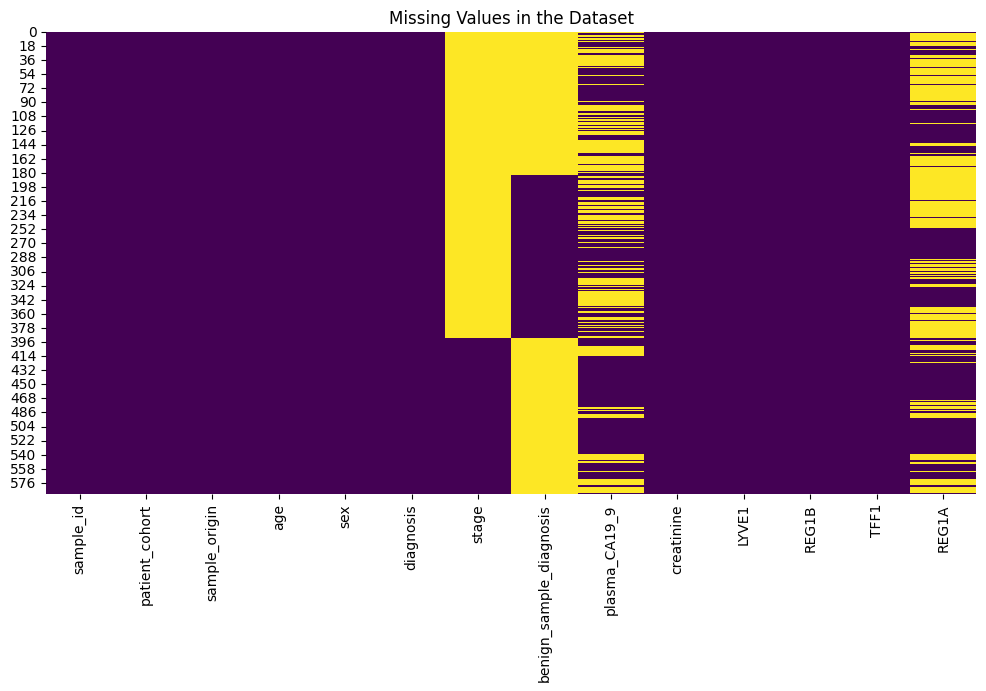

In [2]:
# Display basic information about the dataset
print("Data Types and Non-Null Counts:")
print(data.info())

print("\nSummary Statistics:")
print(data.describe(include='all'))

print("\nMissing Values Per Column:")
print(data.isnull().sum())

# Visualize the missing values in the dataset
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in the Dataset')
plt.show()

Visuallizing the missing values using matplotlib and seaborn

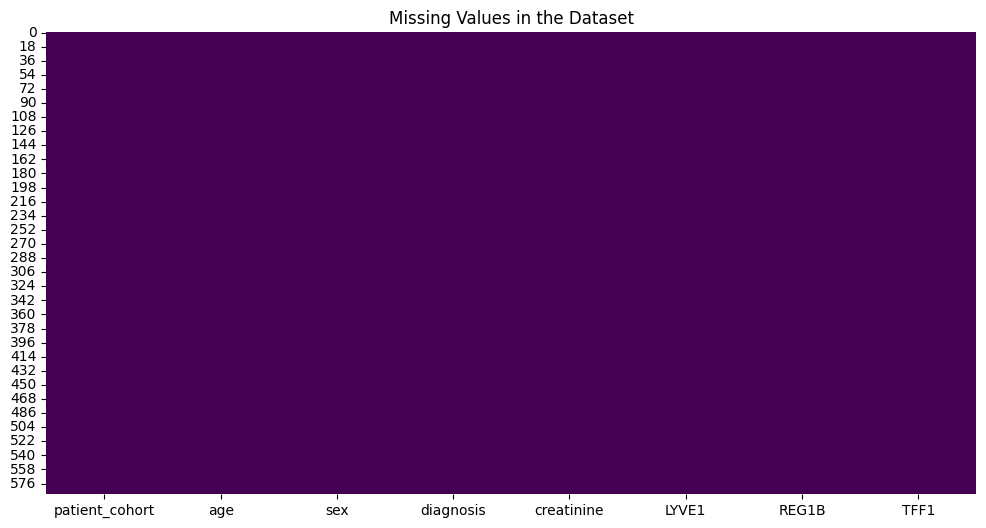

Outliers identified:
    patient_cohort  age sex  diagnosis  creatinine      LYVE1       REG1B  \
144        Cohort1   48   F          1     3.44955   4.512589  138.798730   
151        Cohort1   57   M          1     2.38641   5.953427  543.553920   
210        Cohort2   73   M          2     1.13100   4.860454  704.236000   
230        Cohort2   62   M          2     2.75964   5.883500  201.015000   
252        Cohort1   38   F          2     2.29593   0.009184    5.366192   
..             ...  ...  ..        ...         ...        ...         ...   
580        Cohort1   46   M          3     0.75777  10.578610  206.526460   
582        Cohort2   58   F          3     2.39772   0.289500    6.824000   
583        Cohort2   84   M          3     0.66729   5.764349  950.080000   
584        Cohort2   66   M          3     0.93873   7.085637  815.136000   
589        Cohort1   74   M          3     1.50423   8.200958  411.938275   

            TFF1  
144  1876.588322  
151    97.258522

In [3]:

# Drop  columns with significant missing values.
columns_to_drop = ['stage', 'sample_id', 'sample_origin', 'benign_sample_diagnosis', 'REG1A', 'plasma_CA19_9']
columns_to_drop = [col for col in columns_to_drop if col in data.columns]
data.drop(columns=columns_to_drop, inplace=True)
data.head()

# Visualize the missing values in the dataset again
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in the Dataset')
plt.show()

# Outlier detection using IQR on numeric columns only
numeric_cols = data.select_dtypes(include=[np.number])
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_cols < (Q1 - 1.5 * IQR)) | (numeric_cols > (Q3 + 1.5 * IQR))).any(axis=1)

# Print outliers
print("Outliers identified:")
print(data[outliers])


In [4]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
label_encoders = {}
categorical_columns = ['sex', 'patient_cohort']
for column in categorical_columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# Convert diagnosis to binary
data['diagnosis_binary'] = data['diagnosis'].apply(lambda x: 1 if x == 1 else 0)
data.drop('diagnosis', axis=1, inplace=True)



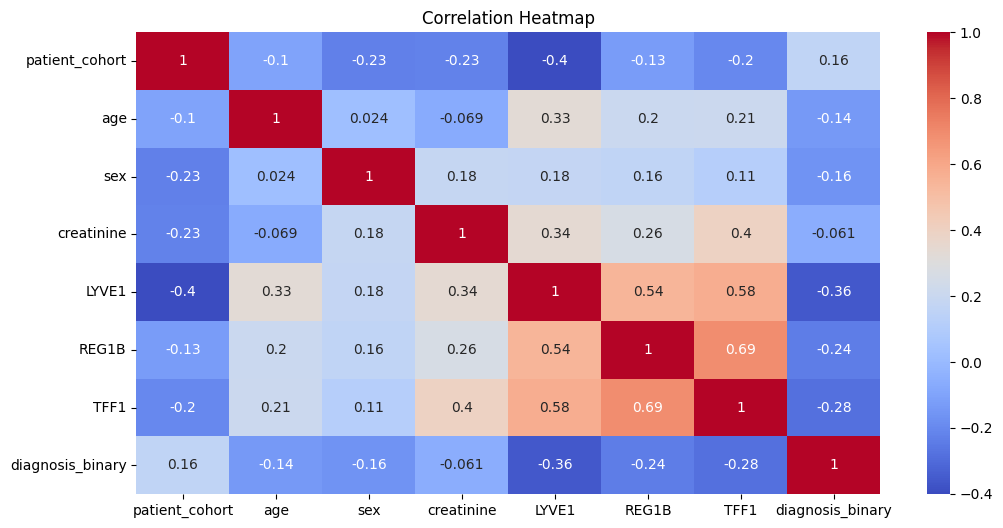

In [5]:
# Correlation heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [7]:
# Check for class imbalance
print("Class Distribution in Target Variable:")
print(data['diagnosis_binary'].value_counts())

Class Distribution in Target Variable:
diagnosis_binary
0    407
1    183
Name: count, dtype: int64


Feature engineering

In [8]:
# Create interaction terms for features with moderate correlations
data['LYVE1_REG1B'] = data['LYVE1'] * data['REG1B']
data['LYVE1_TFF1'] = data['LYVE1'] * data['TFF1']
data['REG1B_TFF1'] = data['REG1B'] * data['TFF1']

# Update feature matrix
X = data.drop(columns=['diagnosis_binary'])
y = data['diagnosis_binary']


In [9]:
from imblearn.over_sampling import SMOTE

# Define features and target variable
X = data.drop(columns=['diagnosis_binary'])
y = data['diagnosis_binary']

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check the distribution of the target variable after SMOTE
resampled_class_distribution = pd.Series(y_resampled).value_counts()
print("Resampled class distribution:\n", resampled_class_distribution)


Resampled class distribution:
 diagnosis_binary
1    407
0    407
Name: count, dtype: int64


In [15]:
#Split 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.preprocessing import StandardScaler

# Normalize the resampled data
numerical_features = ['age', 'creatinine', 'LYVE1', 'REG1B', 'TFF1', 'LYVE1_REG1B', 'LYVE1_TFF1', 'REG1B_TFF1']
scaler = StandardScaler()
X_resampled[numerical_features] = scaler.fit_transform(X_resampled[numerical_features])


In [17]:
# Initialize a Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Initialize GridSearchCV with global variables
grid_search_log_reg = GridSearchCV(estimator=log_reg, param_grid=param_grid_log_reg, cv=cv_method, n_jobs=-1, verbose=2)

# Fit the model
grid_search_log_reg.fit(X_train, y_train)

# Best parameters and estimator
best_params_log_reg = grid_search_log_reg.best_params_
best_log_reg = grid_search_log_reg.best_estimator_

# Evaluate the best model on the test set
y_test_pred_log_reg = best_log_reg.predict(X_test)
test_accuracy_log_reg = accuracy_score(y_test, y_test_pred_log_reg)
classification_report_test_log_reg = classification_report(y_test, y_test_pred_log_reg)

print("Best Parameters (Logistic Regression): ", best_params_log_reg)
print("Test Accuracy (Logistic Regression): ", test_accuracy_log_reg)
print("Test Classification Report (Logistic Regression):\n", classification_report_test_log_reg)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ...........................C=0.01, solver=liblinear; total time=   0.0s
[CV] END ...........................C=0.01, solver=liblinear; total time=   0.0s
[CV] END ...........................C=0.01, solver=liblinear; total time=   0.0s
[CV] END ...........................C=0.01, solver=liblinear; total time=   0.0s
[CV] END ...........................C=0.01, solver=liblinear; total time=   0.0s
[CV] END ..............................C=1, solver=liblinear; total time=   0.0s
[CV] END ..............................C=1, solver=liblinear; total time=   0.0s
[CV] END ..............................C=1, solver=liblinear; total time=   0.0s
[CV] END ..............................C=1, solver=liblinear; total time=   0.0s
[CV] END ............................C=0.1, solver=liblinear; total time=   0.0s
[CV] END ..............................C=1, solver=liblinear; total time=   0.0s
[CV] END ............................C=0.1, solv

/home/ok29267/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/ok29267/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regres

[CV] END .............................C=10, solver=liblinear; total time=   0.0s
[CV] END .............................C=10, solver=liblinear; total time=   0.0s
[CV] END ...............................C=0.01, solver=lbfgs; total time=   0.1s
[CV] END ................................C=0.1, solver=lbfgs; total time=   0.1s
[CV] END ...............................C=0.01, solver=lbfgs; total time=   0.1s
[CV] END ................................C=0.1, solver=lbfgs; total time=   0.1s
[CV] END ................................C=0.1, solver=lbfgs; total time=   0.1s
[CV] END ............................C=100, solver=liblinear; total time=   0.0s
[CV] END ............................C=100, solver=liblinear; total time=   0.0s
[CV] END ...............................C=0.01, solver=lbfgs; total time=   0.1s
[CV] END ............................C=100, solver=liblinear; total time=   0.0s
[CV] END ............................C=100, solver=liblinear; total time=   0.0s
[CV] END ...................

/home/ok29267/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/ok29267/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regres

In [18]:
# Initialize a KNN model
knn = KNeighborsClassifier()

# Initialize GridSearchCV with global variables
grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn, cv=cv_method, n_jobs=-1, verbose=2)

# Fit the model
grid_search_knn.fit(X_train, y_train)

# Best parameters and estimator
best_params_knn = grid_search_knn.best_params_
best_knn = grid_search_knn.best_estimator_

# Evaluate the best model on the test set
y_test_pred_knn = best_knn.predict(X_test)
test_accuracy_knn = accuracy_score(y_test, y_test_pred_knn)
classification_report_test_knn = classification_report(y_test, y_test_pred_knn)

print("Best Parameters (KNN): ", best_params_knn)
print("Test Accuracy (KNN): ", test_accuracy_knn)
print("Test Classification Report (KNN):\n", classification_report_test_knn)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s

[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=5, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=5, we

In [19]:
# Initialize a Random Forest model
rf = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV with global variables
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_grid_rf, n_iter=50, cv=cv_method, verbose=2, random_state=42, n_jobs=-1)

# Fit the model
rf_random.fit(X_resampled, y_resampled)

# Best parameters and estimator
best_params_rf = rf_random.best_params_
best_rf = rf_random.best_estimator_

# Evaluate the best model on the test set
y_test_pred_rf = best_rf.predict(X_test)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
classification_report_test_rf = classification_report(y_test, y_test_pred_rf)

print("Best Parameters (Random Forest): ", best_params_rf)
print("Test Accuracy (Random Forest): ", test_accuracy_rf)
print("Test Classification Report (Random Forest):\n", classification_report_test_rf)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   0.2s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100;

/home/ok29267/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
80 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/home/ok29267/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/ok29267/.local/lib/python3.10/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/home/ok29267/.local/lib/python3.10/site-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/home/ok29267/

Best Parameters (Random Forest):  {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Test Accuracy (Random Forest):  0.652542372881356
Test Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.65      1.00      0.79        77
           1       0.00      0.00      0.00        41

    accuracy                           0.65       118
   macro avg       0.33      0.50      0.39       118
weighted avg       0.43      0.65      0.52       118



/home/ok29267/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ok29267/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ok29267/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
# Initialize an SVM model
svm = SVC()

# Initialize RandomizedSearchCV with global variables
svm_random = RandomizedSearchCV(estimator=svm, param_distributions=param_grid_svm, n_iter=50, cv=cv_method, verbose=2, random_state=42, n_jobs=-1)

# Fit the model
svm_random.fit(X_resampled, y_resampled)

# Best parameters and estimator
best_params_svm = svm_random.best_params_
best_svm = svm_random.best_estimator_

# Evaluate the best model on the test set
y_test_pred_svm = best_svm.predict(X_test)
test_accuracy_svm = accuracy_score(y_test, y_test_pred_svm)
classification_report_test_svm = classification_report(y_test, y_test_pred_svm)

print("Best Parameters (SVM): ", best_params_svm)
print("Test Accuracy (SVM): ", test_accuracy_svm)
print("Test Classification Report (SVM):\n", classification_report_test_svm)


/home/ok29267/.local/lib/python3.10/site-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 32 is smaller than n_iter=50. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=

/home/ok29267/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ok29267/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ok29267/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


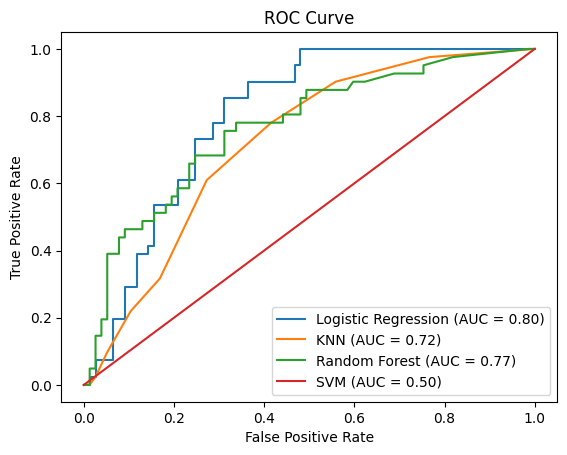

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

# Function to plot ROC curve
def plot_roc_curve(y_test, y_pred_proba, model_name):
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()

# Plot ROC curves for each model
plt.figure()

# Logistic Regression
y_pred_proba_log_reg = best_log_reg.predict_proba(X_test)[:, 1]
plot_roc_curve(y_test, y_pred_proba_log_reg, 'Logistic Regression')

# KNN
y_pred_proba_knn = best_knn.predict_proba(X_test)[:, 1]
plot_roc_curve(y_test, y_pred_proba_knn, 'KNN')

# Random Forest
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]
plot_roc_curve(y_test, y_pred_proba_rf, 'Random Forest')

# SVM (if using probability estimates)
y_pred_proba_svm = best_svm.decision_function(X_test)
plot_roc_curve(y_test, y_pred_proba_svm, 'SVM')

plt.show()
